## Integración de scores de todos los modelos

Une los scores del test set de cada modelo (BERT, DistilRoBERTa, ResNet, LGBM FE, LGBM Binary) en un único DataFrame, matcheando por `PetID`.

In [8]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold
from sklearn.metrics import (
    make_scorer, cohen_kappa_score,
    confusion_matrix, classification_report,
    roc_curve, auc,
)
from sklearn.preprocessing import StandardScaler, label_binarize

OUTPUT_DIR = '../output/'

In [9]:
# Cargar cada archivo y renombrar columnas de scores con prefijo del modelo

bert = pd.read_csv(os.path.join(OUTPUT_DIR, 'scores_bert.csv'))

distilroberta = pd.read_csv(os.path.join(OUTPUT_DIR, 'scores_distilroberta.csv'))

resnet = pd.read_csv(os.path.join(OUTPUT_DIR, 'scores_resnet.csv'))

lgbm_fe = pd.read_csv(os.path.join(OUTPUT_DIR, 'lgbm_fe_test_preds.csv'))
lgbm_fe = lgbm_fe.rename(columns={
    'prob_class_0': 'lgbm_fe_prob_0',
    'prob_class_1': 'lgbm_fe_prob_1',
    'prob_class_2': 'lgbm_fe_prob_2',
    'prob_class_3': 'lgbm_fe_prob_3',
    'prob_class_4': 'lgbm_fe_prob_4',
})

lgbm_binary = pd.read_csv(os.path.join(OUTPUT_DIR, 'lgbm_binary_class0_test_preds.csv'))
lgbm_binary = lgbm_binary.rename(columns={
    'prob_class_0': 'lgbm_binary_prob_0',
    'prob_class_1': 'lgbm_binary_prob_1',
    'prob_class_2': 'lgbm_binary_prob_2',
    'prob_class_3': 'lgbm_binary_prob_3',
    'prob_class_4': 'lgbm_binary_prob_4',
})

print(f'bert:          {bert.shape}')
print(f'distilroberta: {distilroberta.shape}')
print(f'resnet:        {resnet.shape}')
print(f'lgbm_fe:       {lgbm_fe.shape}')
print(f'lgbm_binary:   {lgbm_binary.shape}')

bert:          (2996, 7)
distilroberta: (2996, 7)
resnet:        (2996, 7)
lgbm_fe:       (2999, 6)
lgbm_binary:   (2999, 6)


In [10]:
# Merge por PetID
df = (
    bert
    .merge(distilroberta, on=['PetID', 'AdoptionSpeed'], how='outer')
    .merge(resnet,        on=['PetID', 'AdoptionSpeed'], how='outer')
    .merge(lgbm_fe,       on='PetID',                   how='outer')
    .merge(lgbm_binary,   on='PetID',                   how='outer')
)

print(f'Filas totales (outer join): {len(df)}')
print(f'Columnas: {list(df.columns)}')

Filas totales (outer join): 2999
Columnas: ['PetID', 'AdoptionSpeed', 'bert_prob_0', 'bert_prob_1', 'bert_prob_2', 'bert_prob_3', 'bert_prob_4', 'distilroberta_prob_0', 'distilroberta_prob_1', 'distilroberta_prob_2', 'distilroberta_prob_3', 'distilroberta_prob_4', 'resnet_prob_0', 'resnet_prob_1', 'resnet_prob_2', 'resnet_prob_3', 'resnet_prob_4', 'lgbm_fe_prob_0', 'lgbm_fe_prob_1', 'lgbm_fe_prob_2', 'lgbm_fe_prob_3', 'lgbm_fe_prob_4', 'lgbm_binary_prob_0', 'lgbm_binary_prob_1', 'lgbm_binary_prob_2', 'lgbm_binary_prob_3', 'lgbm_binary_prob_4']


In [11]:
# Revisar cuántos PetIDs tienen scores de todos los modelos
score_cols = [
    'bert_prob_0',
    'distilroberta_prob_0',
    'resnet_prob_0',
    'lgbm_fe_prob_0',
    'lgbm_binary_prob_0',
]
completos = df[score_cols].notna().all(axis=1).sum()
print(f'Registros con scores de los 5 modelos: {completos} / {len(df)}')
print()
print('Nulos por columna:')
print(df[score_cols].isna().sum())

Registros con scores de los 5 modelos: 2996 / 2999

Nulos por columna:
bert_prob_0             3
distilroberta_prob_0    3
resnet_prob_0           3
lgbm_fe_prob_0          0
lgbm_binary_prob_0      0
dtype: int64


In [12]:
# Quedarse solo con los PetIDs que tienen todos los modelos
df_inner = df.dropna(subset=score_cols).reset_index(drop=True)
print(f'Registros completos: {len(df_inner)}')
df_inner.head()

Registros completos: 2996


,PetID,AdoptionSpeed,bert_prob_0,bert_prob_1,bert_prob_2,bert_prob_3,bert_prob_4,distilroberta_prob_0,distilroberta_prob_1,distilroberta_prob_2,...,lgbm_fe_prob_0,lgbm_fe_prob_1,lgbm_fe_prob_2,lgbm_fe_prob_3,lgbm_fe_prob_4,lgbm_binary_prob_0,lgbm_binary_prob_1,lgbm_binary_prob_2,lgbm_binary_prob_3,lgbm_binary_prob_4
0,002230dea,1.0,0.051317,0.297052,0.266167,0.175991,0.209474,0.014389,0.326355,0.395517,...,0.147791,0.226308,0.306141,0.164211,0.155549,0.459330,0.135168,0.135168,0.135168,0.135168
1,0063f83c9,1.0,0.035229,0.302608,0.290595,0.207513,0.164055,0.052800,0.439423,0.250188,...,0.163284,0.197933,0.182322,0.177755,0.278706,0.453368,0.136658,0.136658,0.136658,0.136658
2,0073c33d0,3.0,0.013524,0.202170,0.365855,0.342318,0.076133,0.005879,0.187059,0.466085,...,0.098645,0.229921,0.244918,0.319264,0.107251,0.405807,0.148548,0.148548,0.148548,0.148548
3,00bfa5da9,4.0,0.027138,0.159197,0.167166,0.151891,0.494608,0.008629,0.048042,0.114586,...,0.101851,0.216412,0.193950,0.202321,0.285466,0.399652,0.150087,0.150087,0.150087,0.150087
4,00c19f4fa,2.0,0.021650,0.248485,0.373968,0.270966,0.084932,0.007486,0.096155,0.505851,...,0.117703,0.166101,0.271774,0.230035,0.214388,0.420072,0.144982,0.144982,0.144982,0.144982


In [13]:
cols_order = ['PetID', 'AdoptionSpeed'] + \
    [c for c in df_inner.columns if c not in ['PetID', 'AdoptionSpeed']]

df_final = df_inner[cols_order]
df_final.head(10)

,PetID,AdoptionSpeed,bert_prob_0,bert_prob_1,bert_prob_2,bert_prob_3,bert_prob_4,distilroberta_prob_0,distilroberta_prob_1,distilroberta_prob_2,...,lgbm_fe_prob_0,lgbm_fe_prob_1,lgbm_fe_prob_2,lgbm_fe_prob_3,lgbm_fe_prob_4,lgbm_binary_prob_0,lgbm_binary_prob_1,lgbm_binary_prob_2,lgbm_binary_prob_3,lgbm_binary_prob_4
0,002230dea,1.0,0.051317,0.297052,0.266167,0.175991,0.209474,0.014389,0.326355,0.395517,...,0.147791,0.226308,0.306141,0.164211,0.155549,0.459330,0.135168,0.135168,0.135168,0.135168
1,0063f83c9,1.0,0.035229,0.302608,0.290595,0.207513,0.164055,0.052800,0.439423,0.250188,...,0.163284,0.197933,0.182322,0.177755,0.278706,0.453368,0.136658,0.136658,0.136658,0.136658
2,0073c33d0,3.0,0.013524,0.202170,0.365855,0.342318,0.076133,0.005879,0.187059,0.466085,...,0.098645,0.229921,0.244918,0.319264,0.107251,0.405807,0.148548,0.148548,0.148548,0.148548
3,00bfa5da9,4.0,0.027138,0.159197,0.167166,0.151891,0.494608,0.008629,0.048042,0.114586,...,0.101851,0.216412,0.193950,0.202321,0.285466,0.399652,0.150087,0.150087,0.150087,0.150087
4,00c19f4fa,2.0,0.021650,0.248485,0.373968,0.270966,0.084932,0.007486,0.096155,0.505851,...,0.117703,0.166101,0.271774,0.230035,0.214388,0.420072,0.144982,0.144982,0.144982,0.144982
5,0142670c8,3.0,0.018408,0.220074,0.253750,0.257870,0.249898,0.010782,0.424340,0.284664,...,0.105098,0.204275,0.258144,0.193731,0.238752,0.429962,0.142510,0.142510,0.142510,0.142510
6,015da9e87,0.0,0.043146,0.313742,0.191550,0.152330,0.299233,0.022848,0.385114,0.331384,...,0.291927,0.248252,0.206919,0.161267,0.091635,0.516406,0.120899,0.120899,0.120899,0.120899
7,015fdb354,2.0,0.010047,0.214484,0.371508,0.377503,0.026458,0.008731,0.342759,0.327731,...,0.106010,0.327329,0.226246,0.179373,0.161042,0.442173,0.139457,0.139457,0.139457,0.139457
8,017d966eb,2.0,0.027867,0.272463,0.229154,0.217671,0.252845,0.027507,0.276343,0.285505,...,0.107339,0.176441,0.205165,0.206920,0.304135,0.419482,0.145129,0.145129,0.145129,0.145129
9,017eda6dc,1.0,0.043150,0.319642,0.208450,0.170321,0.258437,0.027712,0.430077,0.312378,...,0.202925,0.244196,0.173169,0.192221,0.187489,0.507028,0.123243,0.123243,0.123243,0.123243


In [14]:
output_path = os.path.join(OUTPUT_DIR, 'scores_integrados.csv')
df_final.to_csv(output_path, index=False)
print(f'Guardado en {output_path}')
print(f'Shape final: {df_final.shape}')

Guardado en ../output/scores_integrados.csv
Shape final: (2996, 27)


---
## Meta-modelo

Usamos los 25 scores de probabilidad (5 modelos × 5 clases) como features para entrenar un meta-modelo.

- **Regresión Logística**: clasificación multiclase directa.
- **Ridge**: trata `AdoptionSpeed` como variable continua (enfoque ordinal), redondea la predicción al entero más cercano.

Para ambos: `GridSearchCV` con 5-fold y kappa cuadrático ponderado como métrica.

In [15]:
feature_cols = [c for c in df_final.columns if '_prob_' in c]
X = df_final[feature_cols].values
y = df_final['AdoptionSpeed'].values.astype(int)

print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'Target: {y.shape}, clases: {np.unique(y)}')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Features (25): ['bert_prob_0', 'bert_prob_1', 'bert_prob_2', 'bert_prob_3', 'bert_prob_4', 'distilroberta_prob_0', 'distilroberta_prob_1', 'distilroberta_prob_2', 'distilroberta_prob_3', 'distilroberta_prob_4', 'resnet_prob_0', 'resnet_prob_1', 'resnet_prob_2', 'resnet_prob_3', 'resnet_prob_4', 'lgbm_fe_prob_0', 'lgbm_fe_prob_1', 'lgbm_fe_prob_2', 'lgbm_fe_prob_3', 'lgbm_fe_prob_4', 'lgbm_binary_prob_0', 'lgbm_binary_prob_1', 'lgbm_binary_prob_2', 'lgbm_binary_prob_3', 'lgbm_binary_prob_4']
Target: (2996,), clases: [0 1 2 3 4]


In [16]:
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

def kappa_ridge(y_true, y_pred):
    y_pred_rounded = np.clip(np.round(y_pred).astype(int), 0, 4)
    return cohen_kappa_score(y_true, y_pred_rounded, weights='quadratic')

kappa_scorer_ridge = make_scorer(kappa_ridge)

In [17]:
cv_logistic = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_logistic = GridSearchCV(
    LogisticRegression(max_iter=1000, solver='lbfgs'),
    param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    scoring=kappa_scorer,
    cv=cv_logistic,
    refit=True,
    n_jobs=-1,
    verbose=1,
)
gs_logistic.fit(X_scaled, y)

print(f'Mejor C:           {gs_logistic.best_params_["C"]}')
print(f'Kappa CV (5-fold): {gs_logistic.best_score_:.4f}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejor C:           0.01
Kappa CV (5-fold): 0.3968


In [18]:
cv_ridge = KFold(n_splits=5, shuffle=True, random_state=42)

gs_ridge = GridSearchCV(
    Ridge(),
    param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
    scoring=kappa_scorer_ridge,
    cv=cv_ridge,
    refit=True,
    n_jobs=-1,
    verbose=1,
)
gs_ridge.fit(X_scaled, y)

print(f'Mejor alpha:       {gs_ridge.best_params_["alpha"]}')
print(f'Kappa CV (5-fold): {gs_ridge.best_score_:.4f}')

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Mejor alpha:       10
Kappa CV (5-fold): 0.3583


In [19]:
resultados = pd.DataFrame({
    'Modelo meta': ['Logistic Regression', 'Ridge (continuo)'],
    'Mejor hiperparámetro': [
        f"C = {gs_logistic.best_params_['C']}",
        f"alpha = {gs_ridge.best_params_['alpha']}",
    ],
    'Kappa CV (5-fold)': [
        round(gs_logistic.best_score_, 4),
        round(gs_ridge.best_score_, 4),
    ],
})

print(resultados.to_string(index=False))
mejor = resultados.loc[resultados['Kappa CV (5-fold)'].idxmax(), 'Modelo meta']
print(f'\nMejor meta-modelo: {mejor}')

        Modelo meta Mejor hiperparámetro  Kappa CV (5-fold)
Logistic Regression             C = 0.01             0.3968
   Ridge (continuo)           alpha = 10             0.3583

Mejor meta-modelo: Logistic Regression


In [20]:
cv_results_logistic = pd.DataFrame(gs_logistic.cv_results_)[['param_C', 'mean_test_score', 'std_test_score']]
cv_results_logistic.columns = ['C', 'kappa_mean', 'kappa_std']
print('Logística:')
print(cv_results_logistic.sort_values('C').to_string(index=False))

print()

cv_results_ridge = pd.DataFrame(gs_ridge.cv_results_)[['param_alpha', 'mean_test_score', 'std_test_score']]
cv_results_ridge.columns = ['alpha', 'kappa_mean', 'kappa_std']
print('Ridge:')
print(cv_results_ridge.sort_values('alpha').to_string(index=False))

Logística:
      C  kappa_mean  kappa_std
  0.001    0.372245   0.039725
  0.010    0.396843   0.035626
  0.100    0.391651   0.030797
  1.000    0.392448   0.031640
 10.000    0.392893   0.031918
100.000    0.392559   0.031978

Ridge:
   alpha  kappa_mean  kappa_std
   0.001    0.356845   0.012227
   0.010    0.356845   0.012227
   0.100    0.356845   0.012227
   1.000    0.357023   0.011900
  10.000    0.358284   0.012219
 100.000    0.356046   0.012627
1000.000    0.328648   0.016909


---
## Análisis de performance por modelo

Matrices de confusión, métricas por clase y curvas ROC-AUC para los 5 modelos base y los 2 meta-modelos.

In [21]:
# Consolidar predicciones y probabilidades de todos los modelos
CLASSES = [0, 1, 2, 3, 4]

models_preds = {}
models_probs = {}  # Solo modelos que producen probabilidades (para ROC)

# Base models: argmax de sus columnas de probabilidad
base_models = {
    'BERT':          'bert',
    'DistilRoBERTa': 'distilroberta',
    'ResNet':        'resnet',
    'LGBM FE':       'lgbm_fe',
    'LGBM Binary':   'lgbm_binary',
}

for name, prefix in base_models.items():
    prob_cols = [f'{prefix}_prob_{i}' for i in CLASSES]
    probs = df_final[prob_cols].values
    models_preds[name] = np.argmax(probs, axis=1)
    models_probs[name] = probs

# Meta-modelos
models_preds['Logistic Meta'] = gs_logistic.best_estimator_.predict(X_scaled)
models_probs['Logistic Meta'] = gs_logistic.best_estimator_.predict_proba(X_scaled)

ridge_raw = gs_ridge.best_estimator_.predict(X_scaled)
models_preds['Ridge Meta'] = np.clip(np.round(ridge_raw).astype(int), 0, 4)
# Ridge no produce probabilidades → no se incluye en ROC

print('Modelos cargados:', list(models_preds.keys()))

Modelos cargados: ['BERT', 'DistilRoBERTa', 'ResNet', 'LGBM FE', 'LGBM Binary', 'Logistic Meta', 'Ridge Meta']


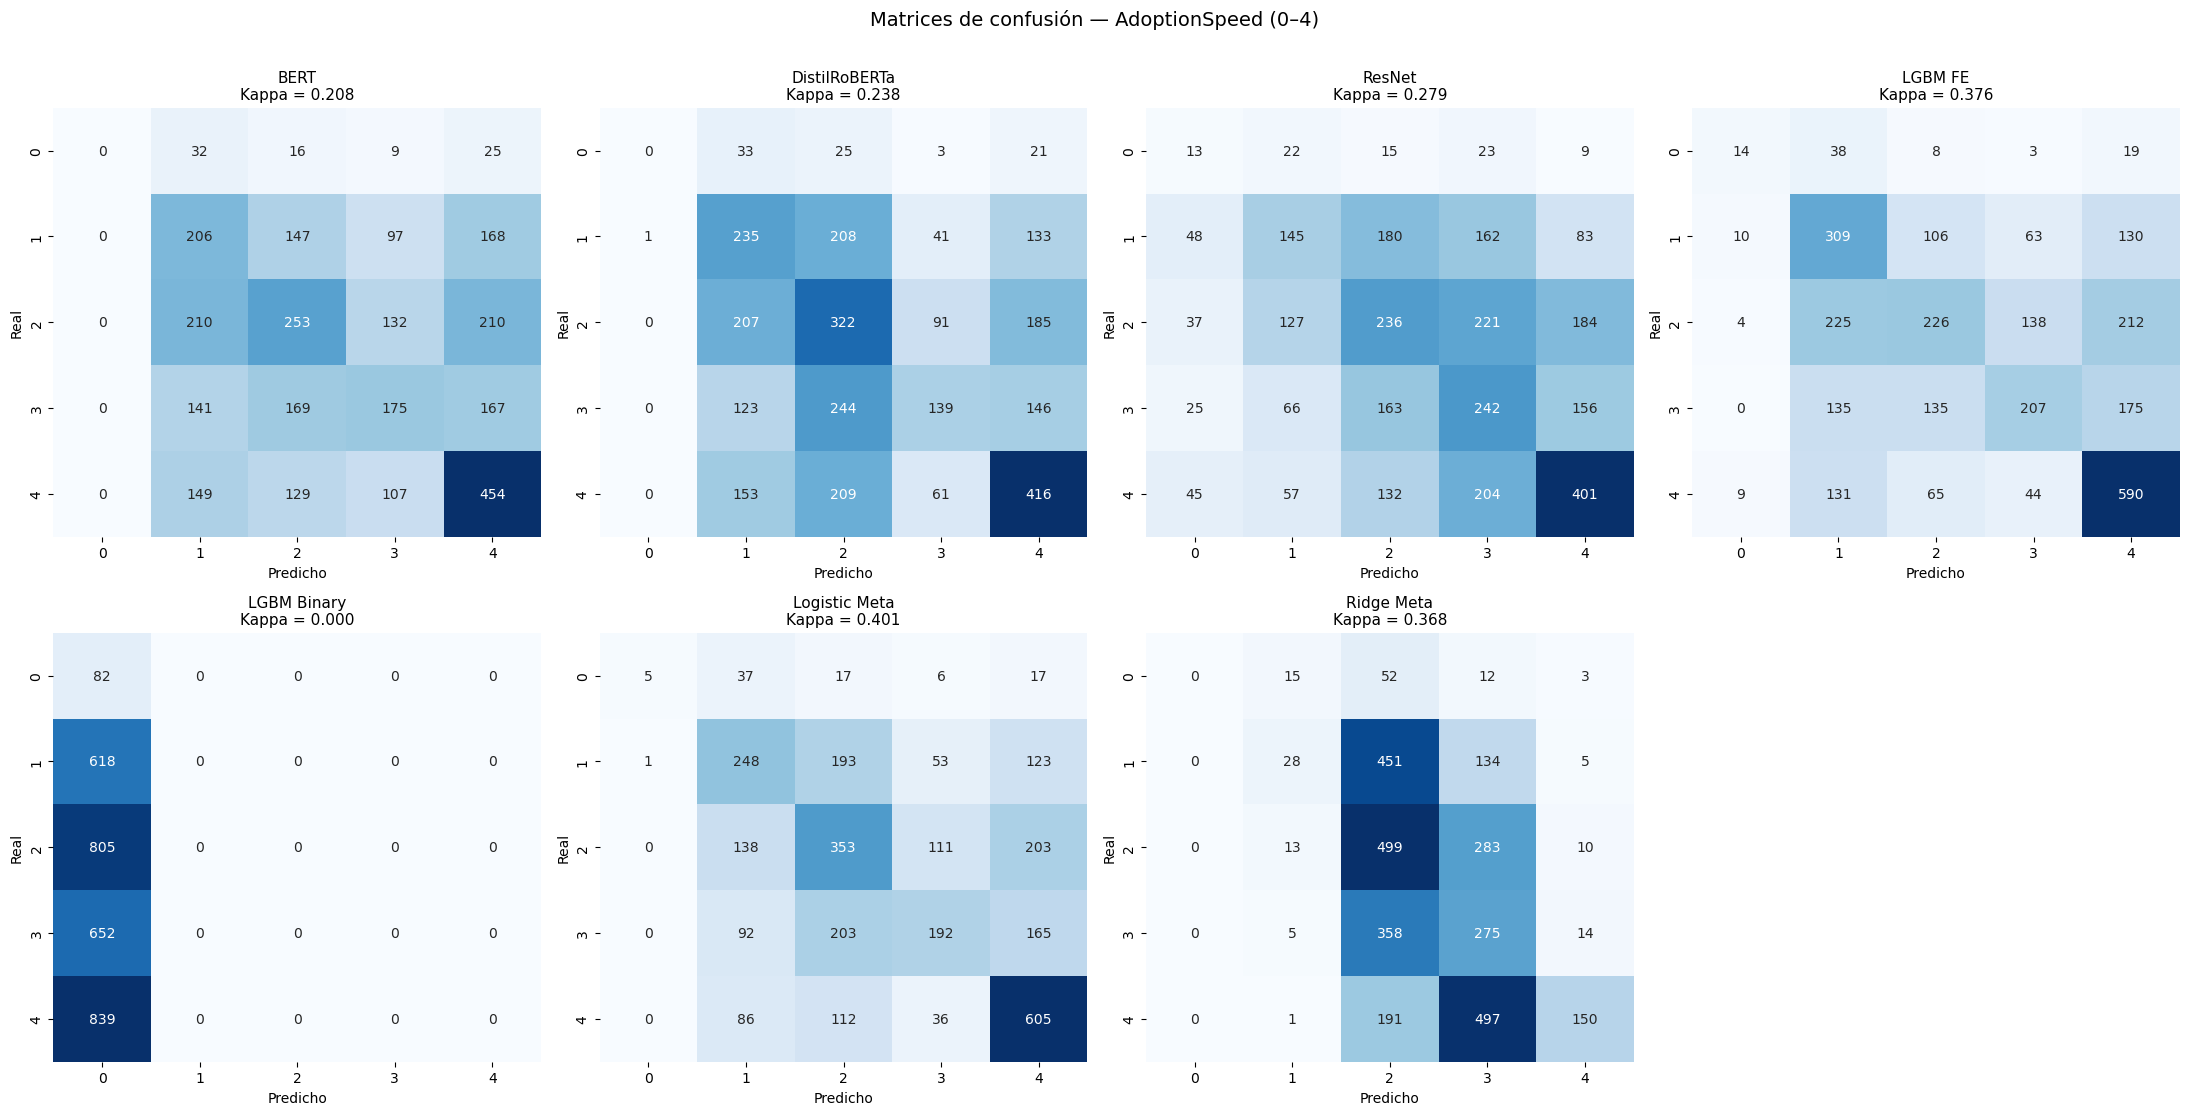

In [22]:
# Matrices de confusión — grilla 2x4
n_models = len(models_preds)
ncols = 4
nrows = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 11))
axes = axes.flatten()

for i, (name, preds) in enumerate(models_preds.items()):
    cm = confusion_matrix(y, preds, labels=CLASSES)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=axes[i],
        cmap='Blues', cbar=False,
        xticklabels=CLASSES, yticklabels=CLASSES,
    )
    kappa = cohen_kappa_score(y, preds, weights='quadratic')
    axes[i].set_title(f'{name}\nKappa = {kappa:.3f}', fontsize=11)
    axes[i].set_xlabel('Predicho')
    axes[i].set_ylabel('Real')

for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Matrices de confusión — AdoptionSpeed (0–4)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


--- BERT ---
              precision  recall  f1-score
0                 0.000   0.000     0.000
1                 0.279   0.333     0.304
2                 0.354   0.314     0.333
3                 0.337   0.268     0.299
4                 0.443   0.541     0.487
accuracy          0.363   0.363     0.363
macro avg         0.283   0.291     0.285
weighted avg      0.350   0.363     0.354

--- DistilRoBERTa ---
              precision  recall  f1-score
0                 0.000   0.000     0.000
1                 0.313   0.380     0.343
2                 0.319   0.400     0.355
3                 0.415   0.213     0.282
4                 0.462   0.496     0.478
accuracy          0.371   0.371     0.371
macro avg         0.302   0.298     0.292
weighted avg      0.370   0.371     0.361

--- ResNet ---
              precision  recall  f1-score
0                 0.077   0.159     0.104
1                 0.348   0.235     0.280
2                 0.325   0.293     0.308
3                 0.284

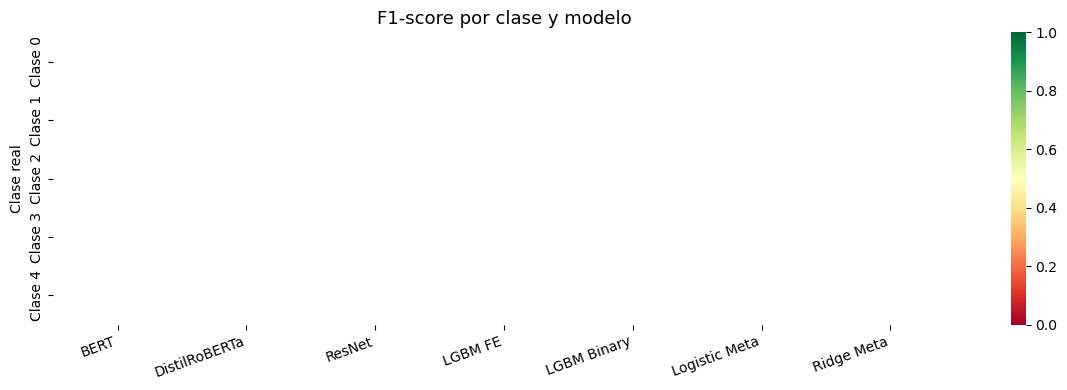

In [23]:
# Métricas por clase — tabla completa y heatmap de F1

f1_data = {}

for name, preds in models_preds.items():
    report = classification_report(y, preds, labels=CLASSES, output_dict=True, zero_division=0)
    f1_data[name] = {cls: report[str(cls)]['f1-score'] for cls in CLASSES}
    print(f'\n--- {name} ---')
    report_df = pd.DataFrame(report).T
    report_df = report_df.drop(columns=['support'], errors='ignore')
    print(report_df.round(3).to_string())

# Heatmap de F1 por clase y modelo
f1_df = pd.DataFrame(f1_data, index=[f'Clase {c}' for c in CLASSES])

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    f1_df, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0, vmax=1, ax=ax, linewidths=0.5,
)
ax.set_title('F1-score por clase y modelo', fontsize=13)
ax.set_ylabel('Clase real')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

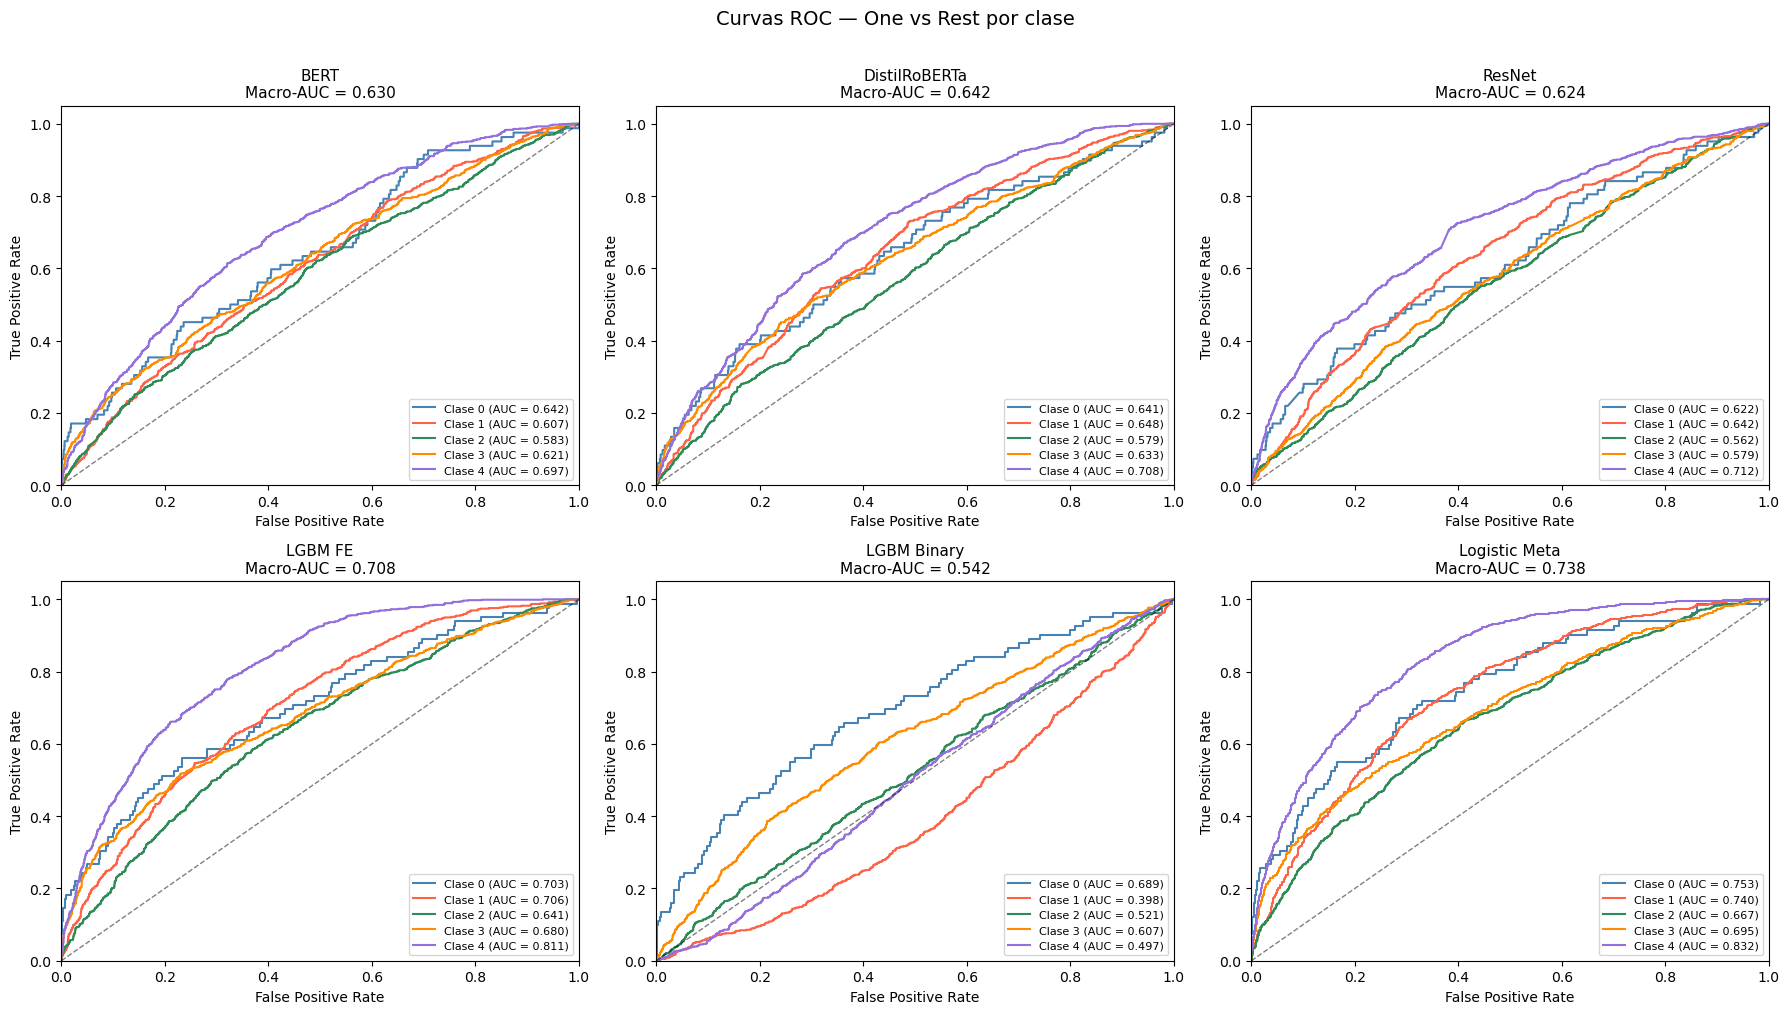

In [24]:
# Curvas ROC-AUC (OvR) — solo modelos con probabilidades
y_bin = label_binarize(y, classes=CLASSES)

colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']

n_roc = len(models_probs)
ncols = 3
nrows = (n_roc + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
axes = axes.flatten()

for i, (name, probs) in enumerate(models_probs.items()):
    ax = axes[i]
    macro_auc = []

    for j, cls in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, j], probs[:, j])
        roc_auc = auc(fpr, tpr)
        macro_auc.append(roc_auc)
        ax.plot(fpr, tpr, color=colors[j], lw=1.5,
                label=f'Clase {cls} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{name}\nMacro-AUC = {np.mean(macro_auc):.3f}', fontsize=11)
    ax.legend(loc='lower right', fontsize=8)

for j in range(n_roc, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Curvas ROC — One vs Rest por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [25]:
# Resumen: Macro-AUC y Kappa de todos los modelos en una tabla
resumen = []
for name, preds in models_preds.items():
    kappa = cohen_kappa_score(y, preds, weights='quadratic')
    if name in models_probs:
        probs = models_probs[name]
        y_bin_tmp = label_binarize(y, classes=CLASSES)
        macro_auc = np.mean([
            auc(*roc_curve(y_bin_tmp[:, j], probs[:, j])[:2])
            for j in range(len(CLASSES))
        ])
    else:
        macro_auc = float('nan')
    resumen.append({'Modelo': name, 'Kappa (quadratic)': round(kappa, 4), 'Macro-AUC': round(macro_auc, 4)})

resumen_df = pd.DataFrame(resumen).sort_values('Kappa (quadratic)', ascending=False)
print(resumen_df.to_string(index=False))

       Modelo  Kappa (quadratic)  Macro-AUC
Logistic Meta             0.4014     0.7375
      LGBM FE             0.3761     0.7083
   Ridge Meta             0.3677        NaN
       ResNet             0.2787     0.6236
DistilRoBERTa             0.2382     0.6416
         BERT             0.2075     0.6301
  LGBM Binary             0.0000     0.5424


In [27]:
# ============================================================
# VALIDACIÓN CRUZADA DEL META-MODELO
# ============================================================

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer
from sklearn.linear_model import LogisticRegression, Ridge
import numpy as np

kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

feature_cols = [c for c in df_inner.columns if 'prob' in c]
X = df_inner[feature_cols].values
y = df_inner['AdoptionSpeed'].values.astype(int)

# Logistic Meta
log_cv = cross_val_score(
    LogisticRegression(max_iter=1000, C=1.0),
    X, y, cv=cv, scoring=kappa_scorer
)
print(f'Logistic Meta — Kappa CV: {log_cv.mean():.4f} ± {log_cv.std():.4f}')

# Ridge Meta
def ridge_kappa_scorer(y_true, y_pred):
    preds = np.clip(np.round(y_pred), 0, 4).astype(int)
    return cohen_kappa_score(y_true, preds, weights='quadratic')

ridge_cv = cross_val_score(
    Ridge(alpha=1.0),
    X, y, cv=cv, scoring=make_scorer(ridge_kappa_scorer)
)
print(f'Ridge Meta     — Kappa CV: {ridge_cv.mean():.4f} ± {ridge_cv.std():.4f}')

# Comparación con kappa sin CV (sobre todo el set)
print(f'\nComparación:')
print(f'Logistic — sin CV: 0.4014  |  con CV: {log_cv.mean():.4f}')
print(f'Ridge    — sin CV: 0.3677  |  con CV: {ridge_cv.mean():.4f}')
print(f'\nSi el kappa con CV es similar al sin CV, el overfitting es bajo.')

Logistic Meta — Kappa CV: 0.3967 ± 0.0300
Ridge Meta     — Kappa CV: 0.3512 ± 0.0218

Comparación:
Logistic — sin CV: 0.4014  |  con CV: 0.3967
Ridge    — sin CV: 0.3677  |  con CV: 0.3512

Si el kappa con CV es similar al sin CV, el overfitting es bajo.
